<a href="https://www.kaggle.com/code/antoninast/fruits-homework-1-10?scriptVersionId=354427616" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
from torchvision.datasets import ImageFolder

In [7]:
data_fruits = "/kaggle/input/datasets/sshikamaru/fruit-recognition/train/train"
dataset = ImageFolder(data_fruits)

In [8]:
len(dataset)

16854

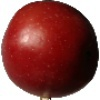

In [9]:
img, label = dataset[100]
img

In [10]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [11]:
label

0

In [14]:
from torchvision import transforms

train_transformer = transforms.Compose([
       transforms.Resize([224, 224]), 
       transforms.RandomHorizontalFlip(p=0.5),  
       transforms.RandomRotation(10),   
       transforms.ToTensor()   
])

In [15]:
train_transformer(img)

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [16]:
test_transformer = transforms.Compose([
       transforms.Resize([224, 224]),   
       transforms.ToTensor()   
])

In [18]:
from torch.utils.data import random_split
train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])

In [19]:
len(train_dataset)

13484

In [20]:
len(test_dataset)

3370

In [21]:
train_dataset[1]

(<PIL.Image.Image image mode=RGB size=100x100>, 17)

In [22]:
from torch.utils.data import Dataset

In [24]:
class TransformDatasetFruits(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [25]:
train_dataset = TransformDatasetFruits(train_dataset, train_transformer)
test_dataset = TransformDatasetFruits(test_dataset, test_transformer)

In [26]:
train_dataset[0]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 24)

In [27]:
from torch.utils.data import DataLoader

In [29]:
train_loader = DataLoader(train_dataset, batch_size=200)
test_loader = DataLoader(test_dataset, batch_size=200)

In [30]:
for img, labels in train_loader:
    break

In [31]:
labels

tensor([24, 17, 31, 19, 31,  1, 14, 30, 28, 17, 13, 22, 17,  4, 12, 24, 16,  4,
        21, 28, 21,  4,  6, 29, 24, 27, 19, 22,  0,  5, 10, 13,  7, 12, 29, 12,
         6, 15, 20,  0,  2,  5, 26, 24, 27, 16, 12, 15, 12,  8,  5, 26, 29, 29,
        10,  7, 12, 15, 15, 15, 16,  0, 23, 21, 14,  9, 30, 16, 17, 26, 25, 30,
         8,  7, 19, 11, 28, 12, 12, 18, 16, 16, 27, 18, 28, 15, 21, 23,  4, 11,
        24, 31, 15,  5, 19, 22,  2, 12,  0,  2,  7, 20, 18, 29, 13, 15, 12, 14,
        12, 12, 22, 25,  7, 22, 10, 24, 32,  9,  2, 18, 17, 13, 25, 21, 21, 14,
         2, 31, 19, 17, 22, 27, 21,  1, 15,  6, 31, 24,  8, 12, 27, 16, 12,  7,
        22, 11, 12, 25, 29, 15, 14, 14,  8,  4, 24, 14,  4, 24,  3, 16, 27, 22,
        20, 11,  4,  2, 17,  0,  7, 32, 14,  6, 25, 26, 26, 24, 28,  0, 20,  9,
         7, 31,  5, 16, 29, 21, 25, 29, 31, 19, 29, 29, 22, 17, 10, 31, 11, 26,
        23, 26])

In [32]:
img.shape

torch.Size([200, 3, 224, 224])